<a href="https://colab.research.google.com/github/flzhfi/deep-learning-assignments/blob/main/week07-CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**[7주차]과제**
- 아래의 과제1), 과제2)의 코드를 완성하시오.
- 모든 코드의 결과를 출력하여, .ipynb의 링크를 **[7주차]/[7주차]과제**에 제출하시오.\
(실습 제출 예시: 7주차_2020XXXX_이름.ipynb 코드 링크)

### - 과제 1의 결과 그래프 사진 업로드: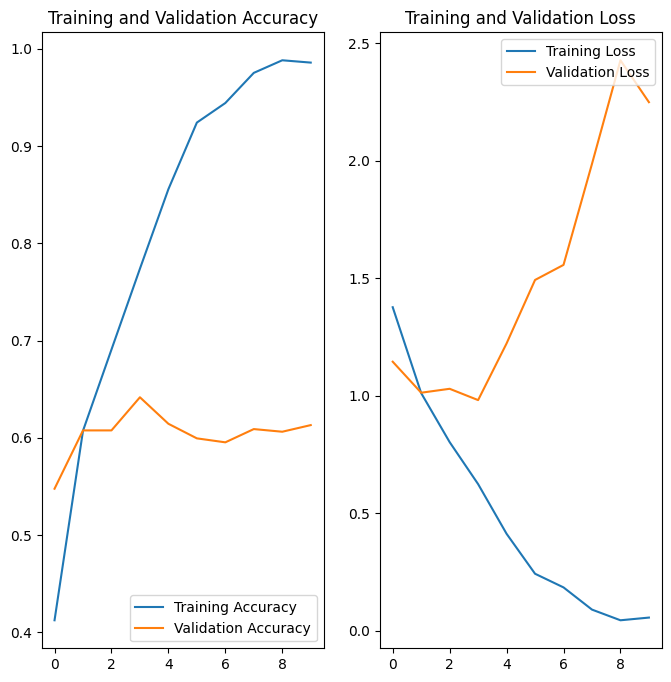

### - 과제 2의 결과 그래프 사진 업로드: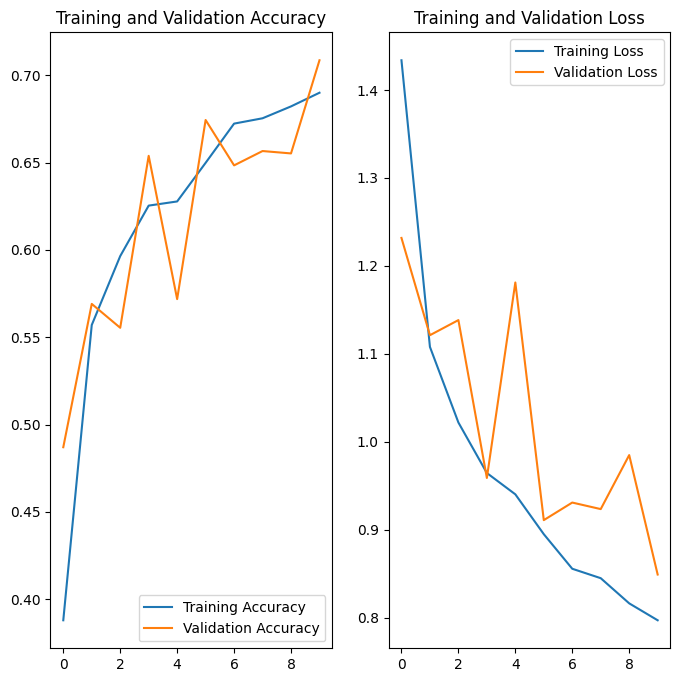

# **[과제 1]** 모델 정의 및 레이어 수정
- 아래의 모델 구조와 동일하게 모델의 구조를 정의하고,model.summary() 출력
- 정의한 모델의 학습 결과 그래프 출력


### **조건** :
1. epoch 수는 10으로 고정
2. Conv2D 함수 안의 파라미터를 조정하여 표기되어있는 baseline 구조와 동일하게 모델 구축

    예시) layer추가
```python
# 입력 Conv2D layer 함수 예시
model.add(layers.Conv2D(filter, kernel_size, padding='same', activation='relu', kernel_initializer=initializer))
# Conv2D layer 함수 예시
model.add(layers.Conv2D(filter, kernel_size, padding='same', activation='relu', kernel_initializer=initializerr))

## baseline 모델 구조
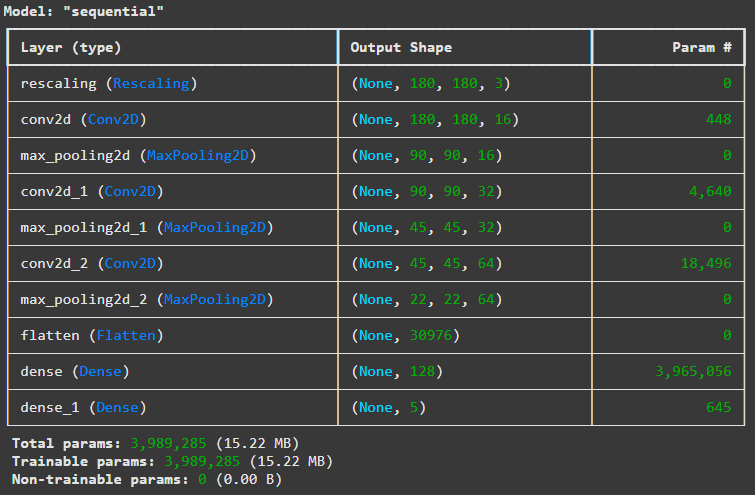

In [ ]:
print("신예진", "2353764")

신예진 2353764


In [ ]:
from google.colab import auth

auth.authenticate_user()
!gcloud config get-value account

snayou2@gmail.com


To take a quick anonymous survey, run:
  $ gcloud survey



In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import PIL
import random

import tensorflow as tf

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input, decode_predictions


import pathlib

In [ ]:
# 시드 고정
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
initializer = tf.keras.initializers.GlorotUniform(seed=seed)

os.environ['PYTONHASHSEED']=str(seed)
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  try:
    tf.config.experimental.set_memory_growth(gpus[0], True)
  except RuntimeError as e:
    print(e)

In [ ]:
# gpu 확인
!nvidia-smi

Wed Apr 15 04:14:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

##데이터 불러오기

In [ ]:
from tensorflow.keras import models, datasets, layers, initializers

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir) / "flower_photos"

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


## 데이터 전처리

In [ ]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [ ]:
batch_size = 32
img_h = 180
img_w = 180

In [ ]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset="training",
    seed = 42,
    image_size = (img_h, img_w),
    batch_size = batch_size
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [ ]:
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset="validation",
    seed = 42,
    image_size = (img_h, img_w),
    batch_size = batch_size
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [ ]:
AUTOTUNE = tf.data.experimental.AUTOTUNE

In [ ]:
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

## normalization 예시

In [ ]:
normalization_layer = layers.Rescaling(1./255)

In [ ]:
normalized_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_dataset))
first_image = image_batch[0]
print(np.min(first_image), np.max(first_image))

0.0 0.93758166


##모델 생성

In [ ]:
# 아래에 있는 basline 구조와 맞게 모델을 설계 하시오
model_1 = models.Sequential()
model_1.add(layers.Rescaling(1./255, input_shape=(180, 180, 3)))
model_1.add(layers.Conv2D(16, 3, padding='same', activation='relu', kernel_initializer=initializer))
model_1.add(layers.MaxPooling2D())
model_1.add(layers.Conv2D(32, 3, padding='same', activation='relu', kernel_initializer=initializer))
model_1.add(layers.MaxPooling2D())
model_1.add(layers.Conv2D(64, 3, padding='same', activation='relu', kernel_initializer=initializer))
model_1.add(layers.MaxPooling2D())
model_1.add(layers.Flatten())
model_1.add(layers.Dense(128, activation='relu', kernel_initializer=initializer))
model_1.add(layers.Dense(5))

model_1.compile(optimizer='adam',
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=['accuracy'])

In [ ]:
model_1.compile(optimizer = 'adam',
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics = ['accuracy'])

In [ ]:
model_1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

## 모델 학습

In [ ]:
epochs=10

history = model_1.fit(
  train_dataset,
  validation_data=val_dataset,
  epochs=epochs
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.4125 - loss: 1.3762 - val_accuracy: 0.5477 - val_loss: 1.1443
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6073 - loss: 1.0106 - val_accuracy: 0.6076 - val_loss: 1.0123
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6907 - loss: 0.8020 - val_accuracy: 0.6076 - val_loss: 1.0290
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7738 - loss: 0.6233 - val_accuracy: 0.6417 - val_loss: 0.9809
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8556 - loss: 0.4119 - val_accuracy: 0.6144 - val_loss: 1.2220
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9240 - loss: 0.2418 - val_accuracy: 0.5995 - val_loss: 1.4922
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9441 - loss: 0.1837 - val_accuracy: 0.5954 - val_loss: 1.5563
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9751 - loss: 0.0891 - val_accuracy: 0.6090 - 

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

best_acc = max(history.history['val_accuracy'])

loss=history.history['loss']
val_loss=history.history['val_loss']

In [ ]:
epochs_range = range(epochs)

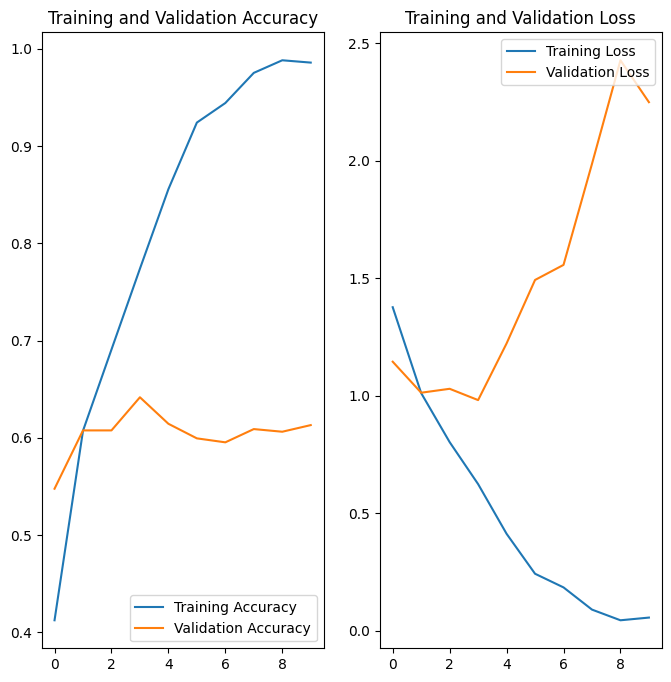

In [ ]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
print(f'best accuracy : {round(best_acc,3)}')

# [과제 2] ImageGenerator를 이용하여 데이터 증대를 하고, 증대된 데이터를 이용해 baseline 모델 학습 후 **학습 결과 그래프 출력**
## 조건 :
1. 데이터 증대는 trainset에만 적용
2. 다양한 증대를 적용하고 변경된 내용 서술 (단, 증대 기법을 최소 2개 이상을 조합해야하며, 증대 조합에 대한 결과를 3개 이상 서술)
3. 모델 구조는 baseline과 동일해야 함
4. 성능은 각 데이터 증대 조합중 학습 loss 그래프가 가장 안정적으로 나왔다고 단되는 모델의 성능을 기입
5. epoch은 10으로 고정





##문제 2-2에 대한 학습 결과 그래프 :
여기에 그래프 그림을 넣어주세요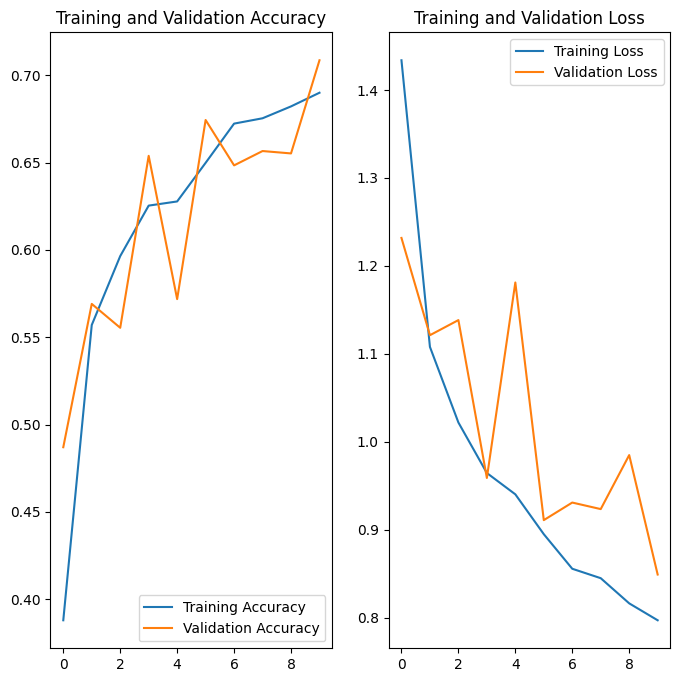

##Generator를 이용한 데이터 증대

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Generator를 이용해 다양한 증대 기법을 활용하시오.
# 힌트 : 데이터 증강은 train dataset에만 이루어집니다.
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.25,
    height_shift_range=0.25,
    horizontal_flip=True,
    zoom_range=0.25,
    shear_range=0.2,
    brightness_range=(0.8, 1.2),
    fill_mode='nearest',
    validation_split = 0.2)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split = 0.2
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size = (180, 180),
    batch_size = 32,
    class_mode='sparse',
    subset = 'training',
    seed = 42
)

val_generator = val_datagen.flow_from_directory(
    data_dir,
    target_size = (180, 180),
    batch_size = 32,
    class_mode='sparse',
    subset = 'validation',
    seed = 42
)

Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.


In [ ]:
# 위에서 정의된 baseline 구조와 동일
Aug_model = models.Sequential()
# Rescaling layer is removed as ImageDataGenerator will handle it
Aug_model.add(layers.Conv2D(16, 3, padding='same', activation='relu', kernel_initializer=initializer, input_shape=(180, 180, 3)))
Aug_model.add(layers.MaxPooling2D())
Aug_model.add(layers.Conv2D(32, 3, padding='same', activation='relu', kernel_initializer=initializer))
Aug_model.add(layers.MaxPooling2D())
Aug_model.add(layers.Conv2D(64, 3, padding='same', activation='relu', kernel_initializer=initializer))
Aug_model.add(layers.MaxPooling2D())
Aug_model.add(layers.Flatten())
Aug_model.add(layers.Dense(128, activation='relu', kernel_initializer=initializer))
Aug_model.add(layers.Dense(5))


Aug_model.compile(optimizer='adam',
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
            metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
epochs=10

Aug_history = Aug_model.fit(
  train_generator,
  validation_data=val_generator,
  epochs=epochs
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 39s 394ms/step - accuracy: 0.3879 - loss: 1.4338 - val_accuracy: 0.4870 - val_loss: 1.2318
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 356ms/step - accuracy: 0.5570 - loss: 1.1078 - val_accuracy: 0.5691 - val_loss: 1.1211
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 366ms/step - accuracy: 0.5965 - loss: 1.0218 - val_accuracy: 0.5554 - val_loss: 1.1383
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 358ms/step - accuracy: 0.6254 - loss: 0.9644 - val_accuracy: 0.6539 - val_loss: 0.9587
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 364ms/step - accuracy: 0.6278 - loss: 0.9401 - val_accuracy: 0.5718 - val_loss: 1.1811
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 364ms/step - accuracy: 0.6499 - loss: 0.8948 - val_accuracy: 0.6744 - val_loss: 0.9108
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 33s 355ms/step - accuracy: 0.6723 - loss: 0.8554 - val_accuracy: 0.6484 - val_loss: 0.9308
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 34s 368ms/step - accuracy: 0.6754 - loss: 0.8447 - val_accu

In [ ]:
Aug_acc = Aug_history.history['accuracy']
Aug_val_acc = Aug_history.history['val_accuracy']

Aug_best_acc = max(Aug_history.history['val_accuracy'])

Aug_loss=Aug_history.history['loss']
Aug_val_loss=Aug_history.history['val_loss']

In [ ]:
epochs_range = range(epochs)

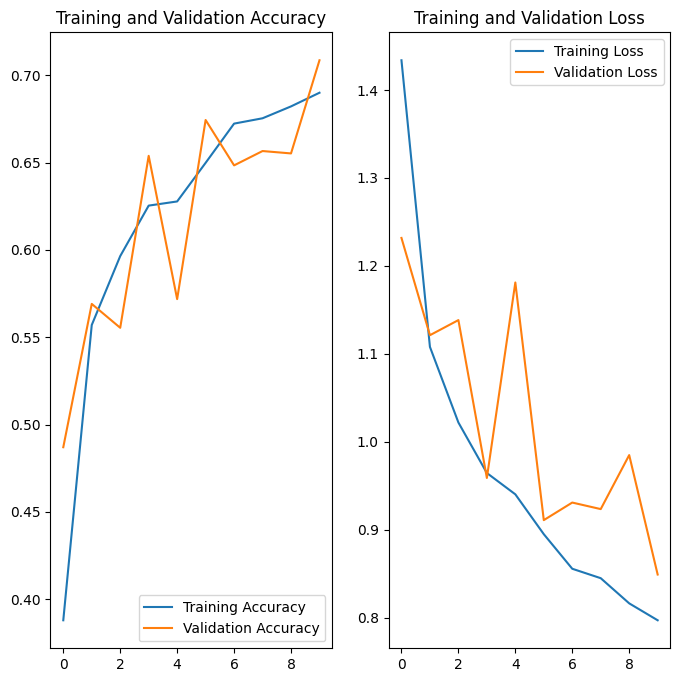

In [ ]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, Aug_acc, label='Training Accuracy')
plt.plot(epochs_range, Aug_val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, Aug_loss, label='Training Loss')
plt.plot(epochs_range, Aug_val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
print(f'best accuracy : {round(Aug_best_acc,3)}')

best accuracy : 0.709
